## Импорты

In [42]:
import sys
import time

import numpy as np
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

import torchvision
import torchvision.transforms as transforms

import matplotlib.pyplot as plt

## Загрузка и предобработка датасета CIFAR10

In [43]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

In [44]:
train_data = torchvision.datasets.CIFAR10(root='./data', train=True, transform=transform, download=True)
test_data = torchvision.datasets.CIFAR10(root='./data', train=False, transform=transform, download=True)

train_loader = torch.utils.data.DataLoader(train_data, batch_size=32, shuffle=True, num_workers=2)
test_loader = torch.utils.data.DataLoader(test_data, batch_size=32, shuffle=True, num_workers=2)

In [45]:
class_names = ['plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

In [46]:
device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print(f"Используется устройство: {device}")

Используется устройство: cuda


## Архитектура сверточных нейросетей

In [47]:
# Архитектура первой сверточной нейросети
class NeuralNet_v1(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(3, 12, 5) # (12, 28, 28)
        self.pool = nn.MaxPool2d(2, 2) # (12, 14, 14)
        self.conv2 = nn.Conv2d(12, 24, 5) # (24, 10, 10) - > pool - (24, 5, 5) - > Flatten (24 * 5 * 5)
        self.fc1 = nn.Linear(24 * 5 * 5, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

In [48]:
# Архитектура второй сверточной нейросети
class NeuralNet_v2(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(3, 32, 3, padding=1) # (32, 32, 32)
        self.pool = nn.MaxPool2d(2, 2) # (32, 16, 16)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1) # (64, 16, 16) - > pool - (64, 8, 8) - > Flatten (64 * 8 * 8)
        self.fc1 = nn.Linear(64 * 8 * 8, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)
        self.bn1 = nn.BatchNorm2d(32)
        self.bn2 = nn.BatchNorm2d(64)
        self.dropout = nn.Dropout(0.3)

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = torch.flatten(x, 1)
        x = self.dropout(F.relu(self.fc1(x)))
        x = self.dropout(F.relu(self.fc2(x)))
        x = self.fc3(x)
        return x

## Обучение

In [49]:
net_v1 = NeuralNet_v1()
net_v2 = NeuralNet_v2()

net_v1.to(device)
net_v2.to(device)

loss_function = nn.CrossEntropyLoss()

optimizer_v1 = optim.SGD(net_v1.parameters(), lr=0.001, momentum=0.9)
optimizer_v2 = optim.Adam(net_v2.parameters(), lr=0.001)

In [50]:
def train_net(model, optimizer, count_epoch):
    losses = []
    
    print('═' * 65)
    print('  ЗАПУСК ПРОЦЕССА ОБУЧЕНИЯ НЕЙРОСЕТИ')
    print('═' * 65)
    print(f'  Всего эпох : {count_epoch}')
    print(f'  Батчей в эпохе: {len(train_loader)}')
    print('═' * 65)
    print(f'  {"Эпоха":<7} | {"Прогресс батчей":<22} | {"Текущий Loss":<12} | {"Время"}')
    print('  ' + '─' * 60)

    start_train_time = time.time()

    for epoch in range(count_epoch):
        epoch_start_time = time.time()
        model.train()
        running_loss = 0.0
        total_batches = len(train_loader)
    
        for i, data in enumerate(train_loader):
            inputs, labels = data[0].to(device), data[1].to(device)
    
            outputs = model(inputs)
            loss = loss_function(outputs, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
    
            running_loss += loss.item()
            
            # Динамическое обновление индикатора внутри эпохи
            if (i + 1) % max(1, total_batches // 10) == 0 or (i + 1) == total_batches:
                percent = int((i + 1) / total_batches * 10)
                # Рисуем заполняющуюся шкалу [■■■■······]
                bar = '■' * percent + '·' * (10 - percent)
                current_avg_loss = running_loss / (i + 1)
                
                # \r возвращает каретку в начало строки, стирая прошлый текст
                sys.stdout.write(
                    f'\r  {epoch+1:>3}/{count_epoch:<3} | [{bar}] {i+1:>4}/{total_batches:<4} | {current_avg_loss:<12.4f} | Ожидание...'
                )
                sys.stdout.flush()

        # Расчет итогов эпохи
        curr_loss = running_loss / total_batches
        losses.append(curr_loss)
        epoch_duration = time.time() - epoch_start_time
        
        # Перезаписываем финальную строку эпохи с точным временем
        sys.stdout.write(
            f'\r  {epoch+1:>3}/{count_epoch:<3} | [{"■"*10}] Готово      | {curr_loss:<12.4f} | {epoch_duration:>5.1f} сек\n'
        )
        sys.stdout.flush()

    total_duration = time.time() - start_train_time
    print('═' * 65)
    print(f'  ПРОЦЕСС УСПЕШНО ЗАВЕРШЕН')
    print(f'  Финальный Loss : {losses[-1]:.4f}')
    print(f'  Общее время    : {total_duration/60:.1f} мин ({total_duration:.1f} сек)')
    print('═' * 65)
    
    return losses

In [51]:
# Обучим первую нейросеть
loss_net_v1 = train_net(net_v1, optimizer_v1, 60)

═════════════════════════════════════════════════════════════════
  ЗАПУСК ПРОЦЕССА ОБУЧЕНИЯ НЕЙРОСЕТИ
═════════════════════════════════════════════════════════════════
  Всего эпох : 60
  Батчей в эпохе: 1563
═════════════════════════════════════════════════════════════════
  Эпоха   | Прогресс батчей        | Текущий Loss | Время
  ────────────────────────────────────────────────────────────
    1/60  | [■■■■■■■■■■] Готово      | 2.2502       |  17.0 сек
    2/60  | [■■■■■■■■■■] Готово      | 1.8281       |  13.9 сек
    3/60  | [■■■■■■■■■■] Готово      | 1.5762       |  14.0 сек
    4/60  | [■■■■■■■■■■] Готово      | 1.4398       |  14.1 сек
    5/60  | [■■■■■■■■■■] Готово      | 1.3252       |  14.4 сек
    6/60  | [■■■■■■■■■■] Готово      | 1.2359       |  14.5 сек
    7/60  | [■■■■■■■■■■] Готово      | 1.1629       |  14.5 сек
    8/60  | [■■■■■■■■■■] Готово      | 1.1036       |  15.0 сек
    9/60  | [■■■■■■■■■■] Готово      | 1.0544       |  14.8 сек
   10/60  | [■■■■■■■■■■] Го

In [52]:
# Обучим вторую нейросеть
loss_net_v2 = train_net(net_v2, optimizer_v2, 60)

═════════════════════════════════════════════════════════════════
  ЗАПУСК ПРОЦЕССА ОБУЧЕНИЯ НЕЙРОСЕТИ
═════════════════════════════════════════════════════════════════
  Всего эпох : 60
  Батчей в эпохе: 1563
═════════════════════════════════════════════════════════════════
  Эпоха   | Прогресс батчей        | Текущий Loss | Время
  ────────────────────────────────────────────────────────────
    1/60  | [■■■■■■■■■■] Готово      | 1.5548       |  18.5 сек
    2/60  | [■■■■■■■■■■] Готово      | 1.2470       |  18.8 сек
    3/60  | [■■■■■■■■■■] Готово      | 1.1314       |  18.9 сек
    4/60  | [■■■■■■■■■■] Готово      | 1.0511       |  19.7 сек
    5/60  | [■■■■■■■■■■] Готово      | 0.9971       |  19.3 сек
    6/60  | [■■■■■■■■■■] Готово      | 0.9436       |  20.4 сек
    7/60  | [■■■■■■■■■■] Готово      | 0.9054       |  19.4 сек
    8/60  | [■■■■■■■■■■] Готово      | 0.8663       |  19.5 сек
    9/60  | [■■■■■■■■■■] Готово      | 0.8306       |  20.1 сек
   10/60  | [■■■■■■■■■■] Го

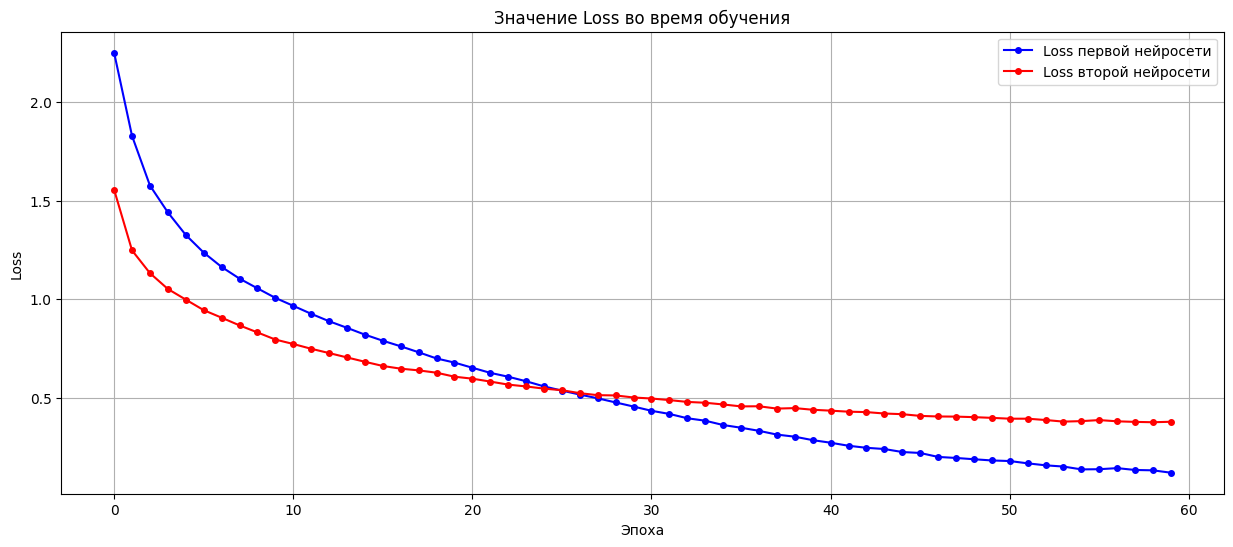

In [53]:
plt.figure(figsize=(15, 6))

# Отрисовка первой нейросети (синий цвет)
plt.plot(loss_net_v1, 'o-', color='blue', label='Loss первой нейросети', ms=4)

# Отрисовка второй нейросети (красный цвет)
plt.plot(loss_net_v2, 'o-', color='red', label='Loss второй нейросети', ms=4)

# Настройка внешнего вида
plt.title('Значение Loss во время обучения')
plt.xlabel('Эпоха')
plt.ylabel('Loss')
plt.grid(True)
plt.legend()

plt.savefig('loss_comparison.png', dpi=300, bbox_inches='tight')
# Отображение графика
plt.show()

In [54]:
torch.save(net_v1.state_dict(), "model/net_v1.pth")
torch.save(net_v2.state_dict(), "model/net_v2.pth")
print("Saved PyTorch Model State to net_v1.pth")
print("Saved PyTorch Model State to net_v2.pth")

Saved PyTorch Model State to net_v1.pth
Saved PyTorch Model State to net_v2.pth


## Валидация

In [55]:
net_load_v1 = NeuralNet_v1()
net_load_v2 = NeuralNet_v2()
net_load_v1.load_state_dict(torch.load("model/net_v1.pth", weights_only=True))
net_load_v2.load_state_dict(torch.load("model/net_v2.pth", weights_only=True))

<All keys matched successfully>

In [56]:
def eval_net(model):
    correct = 0
    total = 0
    
    model.eval()
    
    with torch.no_grad():
        for data in test_loader:
            images, labels = data
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    accuracy = 100 * correct / total
    return accuracy

In [57]:
print(f"Accuracy первой модели: {eval_net(net_load_v1)}")
print(f"Accuracy второй модели: {eval_net(net_load_v2)}")

Accuracy первой модели: 66.24
Accuracy второй модели: 73.11


## Классификация изображений

In [58]:
new_transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

In [59]:
def load_image(image_path):
    image = Image.open(image_path)
    image = new_transform(image)
    image = image.unsqueeze(0)
    return image

In [60]:
def classification_pic(model):
    true_class_names = ['plane', 'plane', 'car', 'car', 'bird', 'bird', 'cat', 'cat',
                        'deer', 'deer', 'dog', 'dog', 'frog', 'frog', 'horse', 'horse', 
                        'ship', 'ship', 'truck', 'truck', 'plane', 'plane', 'car', 'car', 
                        'bird', 'bird', 'cat', 'cat', 'deer', 'deer', 'dog', 'dog', 'frog', 
                        'frog', 'horse', 'horse', 'ship', 'ship', 'truck', 'truck']
    
    image_paths = [f"pic/example{i}.jpg" for i in range(1, 41)]
    images = [load_image(img) for img in image_paths]
    
    print('═' * 70)
    print('  РЕЗУЛЬТАТЫ ТЕСТИРОВАНИЯ МОДЕЛИ (CLASSIFICATION)')
    print('═' * 70)
    print(f'  {"№":>2} | {"Файл":<18} | {"Предсказание":<14} | {"Реальный класс":<14} | {"Статус"}')
    print('  ' + '─' * 65)

    coincidences = 0
    model.eval()
    with torch.no_grad():
        for i, image in enumerate(images):
            output = model(image)
            _, predicted = torch.max(output, 1)
            
            pred_name = class_names[predicted.item()]
            real_name = true_class_names[i]
            img_file = f"example{i+1}.jpg"
            
            if pred_name == real_name:
                coincidences += 1
                status = "✅ ОК"
            else:
                status = "❌ Ошибка"
                
            print(f'  {i+1:>2} | {img_file:<18} | {pred_name:<14} | {real_name:<14} | {status}')
            
    print('═' * 70)
    accuracy = (coincidences / len(true_class_names)) * 100
    print(f'  ИТОГ: {coincidences} из {len(true_class_names)} совпадений ({accuracy:.1f}%)')
    print('═' * 70)

In [61]:
classification_pic(net_load_v1)

══════════════════════════════════════════════════════════════════════
  РЕЗУЛЬТАТЫ ТЕСТИРОВАНИЯ МОДЕЛИ (CLASSIFICATION)
══════════════════════════════════════════════════════════════════════
   № | Файл               | Предсказание   | Реальный класс | Статус
  ─────────────────────────────────────────────────────────────────
   1 | example1.jpg       | plane          | plane          | ✅ ОК
   2 | example2.jpg       | plane          | plane          | ✅ ОК
   3 | example3.jpg       | car            | car            | ✅ ОК
   4 | example4.jpg       | frog           | car            | ❌ Ошибка
   5 | example5.jpg       | bird           | bird           | ✅ ОК
   6 | example6.jpg       | dog            | bird           | ❌ Ошибка
   7 | example7.jpg       | dog            | cat            | ❌ Ошибка
   8 | example8.jpg       | dog            | cat            | ❌ Ошибка
   9 | example9.jpg       | deer           | deer           | ✅ ОК
  10 | example10.jpg      | deer           | deer   

In [62]:
classification_pic(net_load_v2)

══════════════════════════════════════════════════════════════════════
  РЕЗУЛЬТАТЫ ТЕСТИРОВАНИЯ МОДЕЛИ (CLASSIFICATION)
══════════════════════════════════════════════════════════════════════
   № | Файл               | Предсказание   | Реальный класс | Статус
  ─────────────────────────────────────────────────────────────────
   1 | example1.jpg       | plane          | plane          | ✅ ОК
   2 | example2.jpg       | plane          | plane          | ✅ ОК
   3 | example3.jpg       | truck          | car            | ❌ Ошибка
   4 | example4.jpg       | car            | car            | ✅ ОК
   5 | example5.jpg       | bird           | bird           | ✅ ОК
   6 | example6.jpg       | bird           | bird           | ✅ ОК
   7 | example7.jpg       | cat            | cat            | ✅ ОК
   8 | example8.jpg       | cat            | cat            | ✅ ОК
   9 | example9.jpg       | deer           | deer           | ✅ ОК
  10 | example10.jpg      | deer           | deer           | ✅ 

## Визуализация работы сверточных слоев

In [63]:
def visualize_layers(model, single_image, device='cpu'):
    # Переводим модель в режим оценки и на нужный девайс
    model.eval()
    model.to(device)
    
    # Готовим картинку: добавляем размерность батча -> [1, 3, H, W]
    if len(single_image.shape) == 3:
        input_tensor = single_image.unsqueeze(0).to(device)
    else:
        input_tensor = single_image.to(device)
        
    # Словарь для хранения промежуточных картинок
    activations = {}
    hooks = []

    # Функция-колбэк для хука
    def make_hook(layer_name):
        def hook(m, i, o):
            activations[layer_name] = o.detach().cpu()
        return hook

    # Автоматически регистрируем хуки на ВСЕ слои Conv2d в архитектуре
    conv_counter = 1
    for name, module in model.named_modules():
        if isinstance(module, torch.nn.Conv2d):
            layer_id = f"Conv2d_{conv_counter} ({name})"
            hook_ref = module.register_forward_hook(make_hook(layer_id))
            hooks.append(hook_ref)
            conv_counter += 1

    # Проверяем, нашлись ли слои
    if not activations and not hooks:
        print("Слои Conv2d не найдены в этой модели.")
        return

    # Пропускаем картинку через сеть (хуки сработают автоматически)
    with torch.no_grad():
        _ = model(input_tensor)

    # Удаляем хуки, чтобы они не тратили память при последующей работе
    for h in hooks:
        h.remove()

    # Отрисовываем карты признаков для каждого найденного слоя
    for layer_name, features in activations.items():
        features = features.squeeze(0) # Убираем батч -> [channels, H, W]
        num_channels = features.shape[0]
        
        # Настраиваем сетку: максимум 8 колонок в ряд
        cols = min(8, num_channels)
        rows = (num_channels + cols - 1) // cols
        
        fig, axes = plt.subplots(rows, cols, figsize=(cols * 2, rows * 2))
        fig.suptitle(f'Слой: {layer_name} | Каналов: {num_channels}', fontsize=14, weight='bold')
        
        # Превращаем массив осей в плоский список для удобства итерации
        if num_channels == 1:
            axes = [axes]
        else:
            axes = axes.flatten() if hasattr(axes, 'flatten') else [axes]
            
        for i in range(len(axes)):
            ax = axes[i]
            if i < num_channels:
                # Берем i-й канал и рисуем его
                channel_map = features[i].numpy()
                ax.imshow(channel_map, cmap='viridis')
            ax.axis('off') # Прячем оси координат
            
        plt.tight_layout()
        plt.show()

In [64]:
image_paths = "pic/example1.jpg"
test_image = load_image(image_paths)

### Сверточные слои первой модели

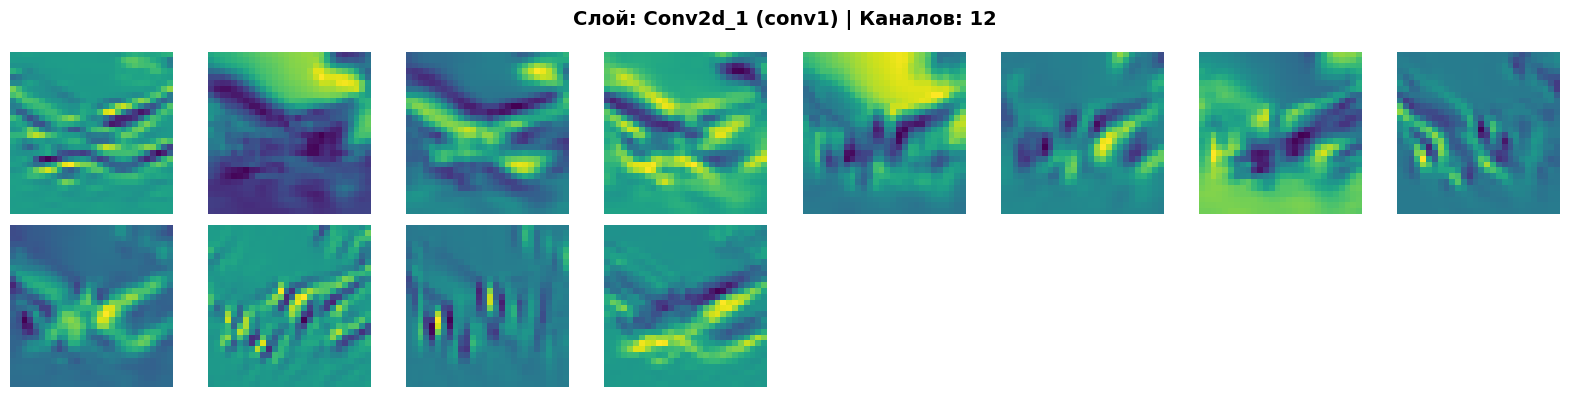

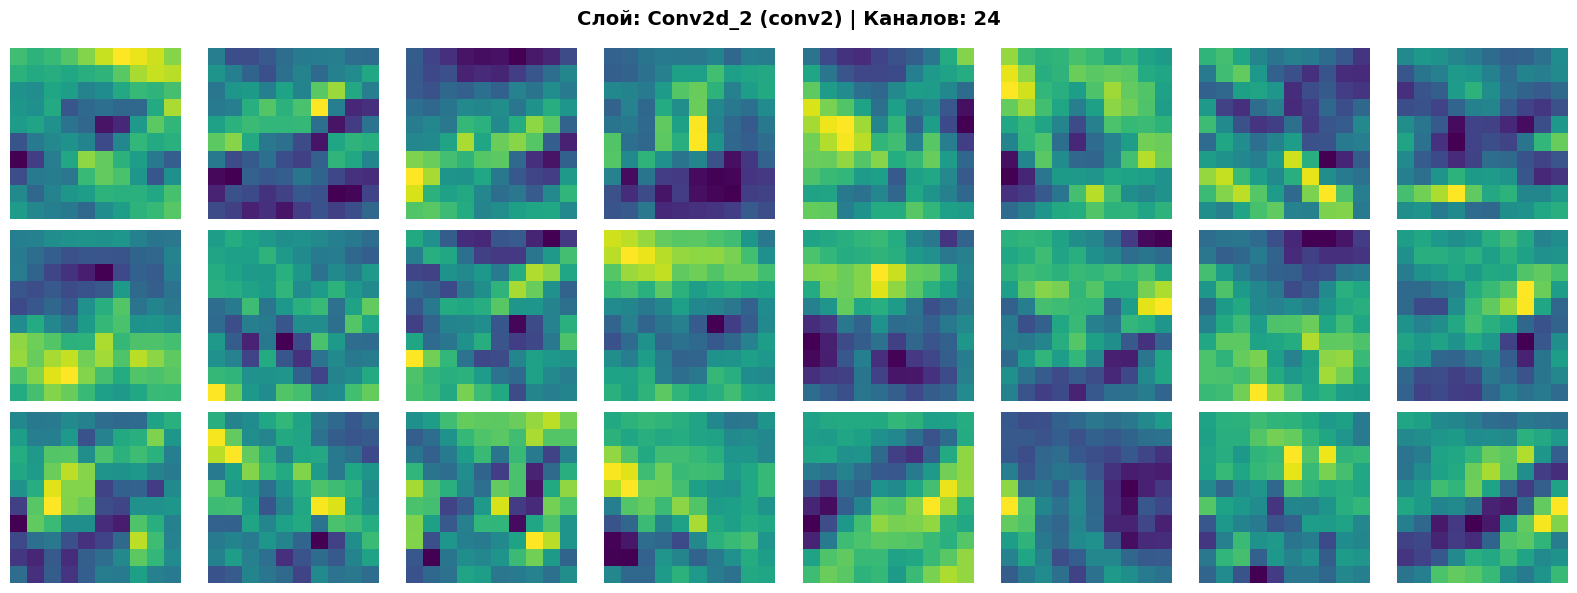

In [65]:
visualize_layers(net_load_v1, test_image, device=device)

### Сверточные слои второй модели

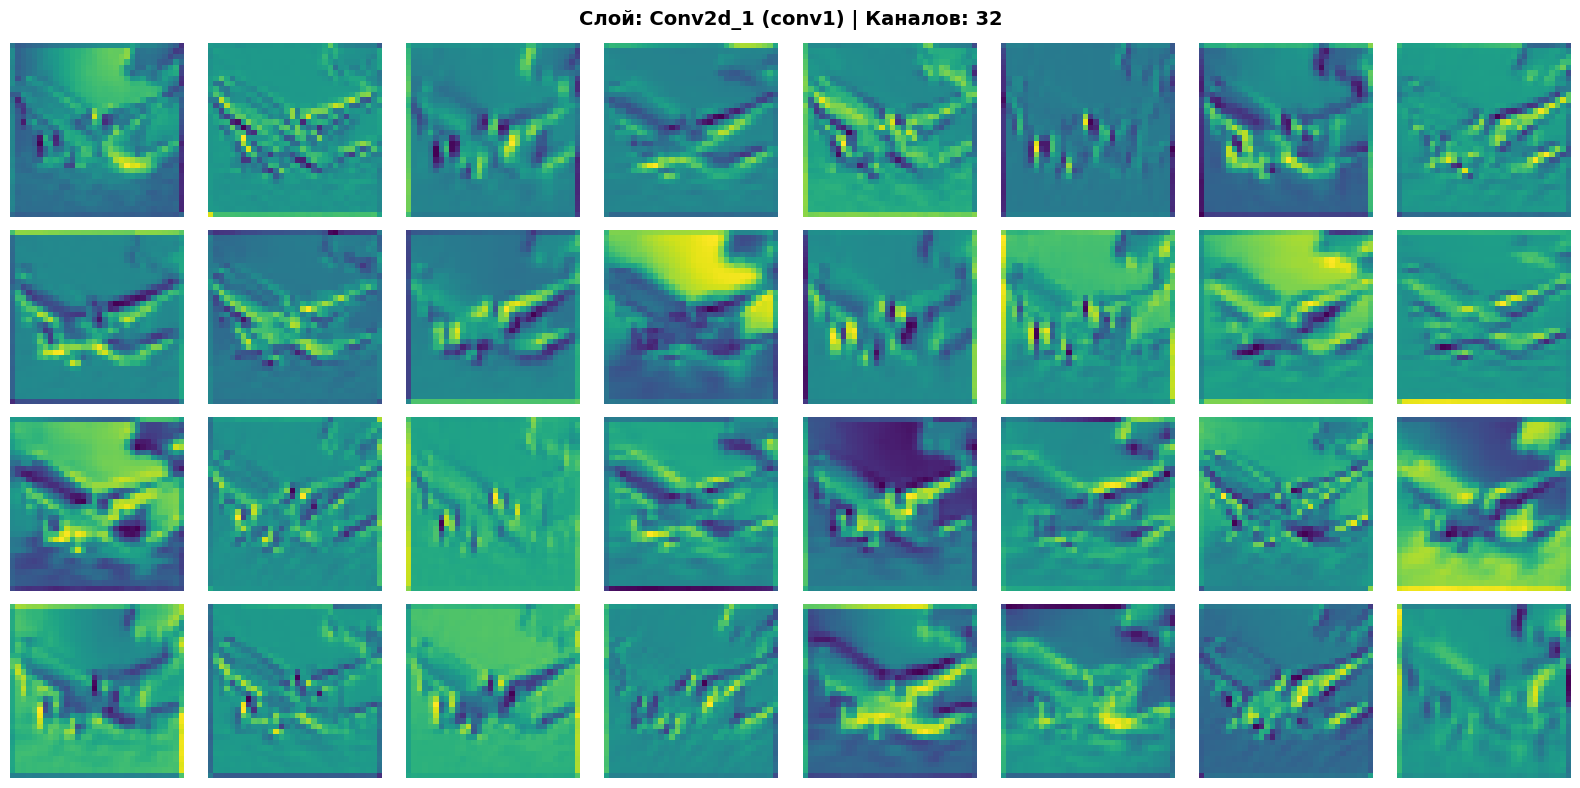

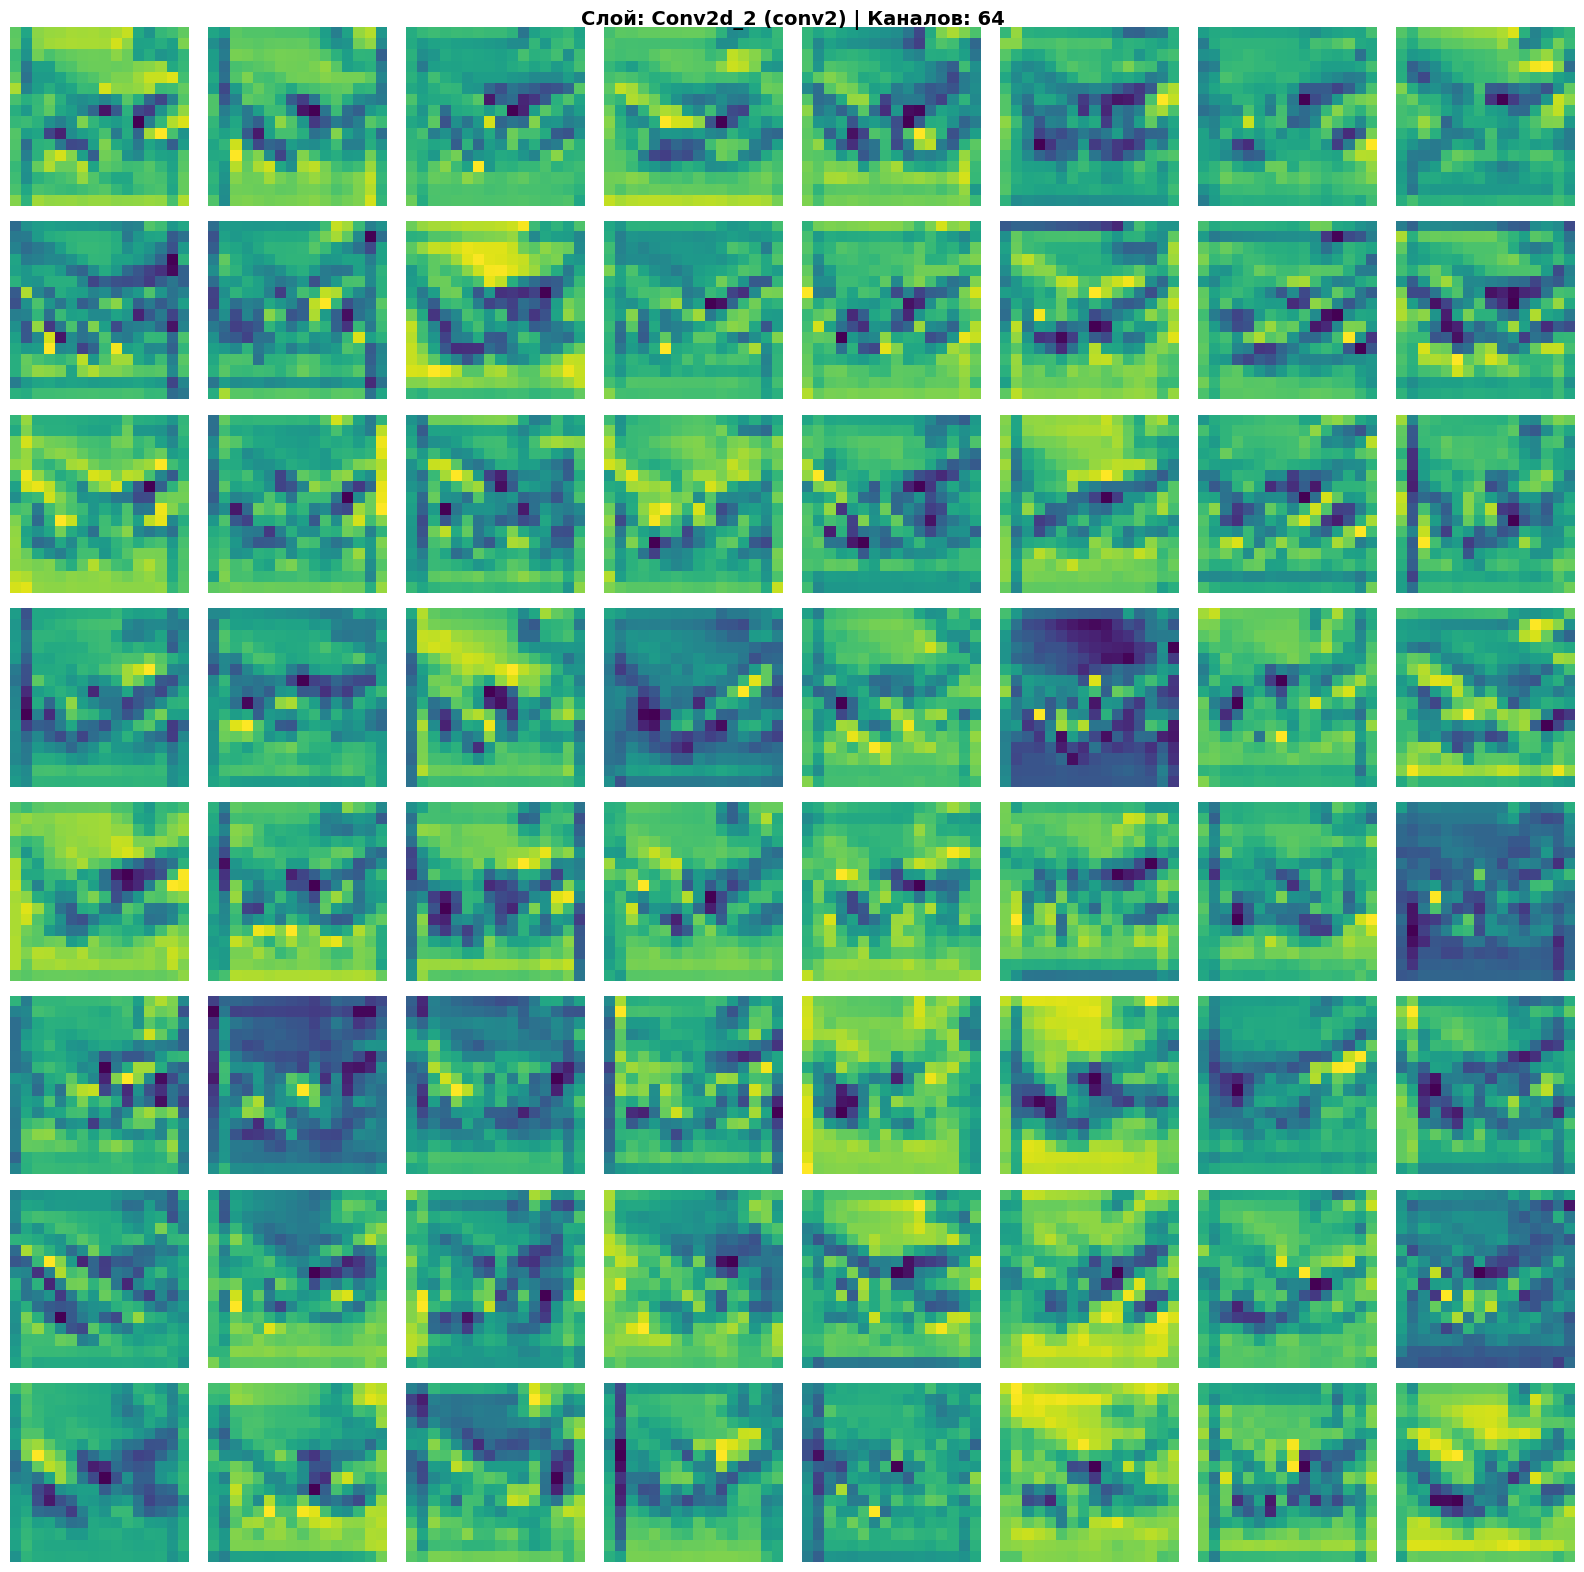

In [66]:
visualize_layers(net_load_v2, test_image, device=device)